<a href="https://colab.research.google.com/github/samteccmrj/pythonadaptativo/blob/main/curso_python_adaptativo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# BLOCO 1 — Carregar e inspecionar o dataset
# ============================================================

import pandas as pd
import numpy as np

arquivo = "python_adaptativo.xlsx"

df = pd.read_excel(arquivo)

print("="*80)
print("DIMENSÕES DO DATASET")
print("="*80)
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

print("\n" + "="*80)
print("COLUNAS")
print("="*80)
print(df.columns.tolist())

print("\n" + "="*80)
print("PRIMEIRAS LINHAS")
print("="*80)
display(df.head())

print("\n" + "="*80)
print("TIPOS DE DADOS")
print("="*80)
print(df.dtypes)

print("\n" + "="*80)
print("VALORES AUSENTES POR COLUNA")
print("="*80)
print(df.isnull().sum())

print("\n" + "="*80)
print("DISTRIBUIÇÃO POR TURMA")
print("="*80)
print(df["turma_ano"].value_counts().sort_index())

print("\n" + "="*80)
print("DISTRIBUIÇÃO POR ANO ESCOLAR")
print("="*80)
print(df["ano_escolar"].value_counts())

print("\n" + "="*80)
print("ESTATÍSTICAS DESCRITIVAS — PRÉ E PÓS-TESTE")
print("="*80)
print(df[["nota_pret", "nota_post"]].describe())

print("\n" + "="*80)
print("ESTATÍSTICAS DESCRITIVAS — UX")
print("="*80)
ux_cols = ["ux_01", "ux_02", "ux_03", "ux_04", "ux_05"]
print(df[ux_cols].describe())

DIMENSÕES DO DATASET
Linhas: 24
Colunas: 26

COLUNAS
['turma_ano', 'aluno', 'ano_escolar', 't_01', 'tc_01', 't_02', 'tc_02', 't_03', 'tc_03', 't_04', 'tc_04', 't_05', 'tc_05', 't_06', 'tc_06', 't_07', 'tc_07', 't_08', 'tc_08', 'nota_pret', 'nota_post', 'ux_01', 'ux_02', 'ux_03', 'ux_04', 'ux_05']

PRIMEIRAS LINHAS


,turma_ano,aluno,ano_escolar,t_01,tc_01,t_02,tc_02,t_03,tc_03,t_04,...,tc_07,t_08,tc_08,nota_pret,nota_post,ux_01,ux_02,ux_03,ux_04,ux_05
0,2025,aluno_01,2º Ano EM,1,-1,0,1,1,-1,0,...,-1,1,-1,4,7,5,5,5,4,5
1,2025,aluno_02,2º Ano EM,0,1,1,-1,1,-1,1,...,-1,1,-1,8,10,4,5,5,3,5
2,2025,aluno_03,8º Ano EF,0,1,1,-1,1,-1,0,...,-1,1,-1,5,9,5,5,4,4,5
3,2025,aluno_04,2º Ano EM,0,1,0,1,1,-1,1,...,-1,1,-1,2,7,4,5,5,4,5
4,2025,aluno_05,2º Ano EM,0,1,1,-1,1,-1,0,...,-1,0,1,4,7,4,4,5,4,4



TIPOS DE DADOS
turma_ano       int64
aluno          object
ano_escolar    object
t_01            int64
tc_01           int64
t_02            int64
tc_02           int64
t_03            int64
tc_03           int64
t_04            int64
tc_04           int64
t_05            int64
tc_05           int64
t_06            int64
tc_06           int64
t_07            int64
tc_07           int64
t_08            int64
tc_08           int64
nota_pret       int64
nota_post       int64
ux_01           int64
ux_02           int64
ux_03           int64
ux_04           int64
ux_05           int64
dtype: object

VALORES AUSENTES POR COLUNA
turma_ano      0
aluno          0
ano_escolar    0
t_01           0
tc_01          0
t_02           0
tc_02          0
t_03           0
tc_03          0
t_04           0
tc_04          0
t_05           0
tc_05          0
t_06           0
tc_06          0
t_07           0
tc_07          0
t_08           0
tc_08          0
nota_pret      0
nota_post      0
ux_01       

In [ ]:
# ============================================================
# BLOCO 2 — Variáveis derivadas
# ============================================================

# -------------------------------
# Ganho bruto
# -------------------------------
df["ganho_bruto"] = df["nota_post"] - df["nota_pret"]

# -------------------------------
# Ganho normalizado (Hake)
# -------------------------------
def calcular_hake(pre, pos):
    if pre == 10:
        return 0  # evita divisão por zero
    return (pos - pre) / (10 - pre)

df["ganho_hake"] = df.apply(lambda x: calcular_hake(x["nota_pret"], x["nota_post"]), axis=1)

# -------------------------------
# Total de acertos nos tópicos principais
# -------------------------------
topicos = [f"t_0{i}" for i in range(1,9)]
df["acertos_topicos"] = df[topicos].sum(axis=1)

# -------------------------------
# Total de reforços acessados
# (contando quando tc != -1)
# -------------------------------
reforcos = [f"tc_0{i}" for i in range(1,9)]
df["qtd_reforcos"] = df[reforcos].apply(lambda x: (x != -1).sum(), axis=1)

# -------------------------------
# Acertos nos reforços
# -------------------------------
df["acertos_reforco"] = df[reforcos].apply(lambda x: (x == 1).sum(), axis=1)

# -------------------------------
# Média UX
# -------------------------------
ux_cols = ["ux_01", "ux_02", "ux_03", "ux_04", "ux_05"]
df["ux_media"] = df[ux_cols].mean(axis=1)

# ============================================================
# PRINTS
# ============================================================

print("="*80)
print("GANHO BRUTO")
print("="*80)
print(df["ganho_bruto"].describe())

print("\n" + "="*80)
print("GANHO NORMALIZADO (HAKE)")
print("="*80)
print(df["ganho_hake"].describe())

print("\n" + "="*80)
print("ACERTOS NOS TÓPICOS")
print("="*80)
print(df["acertos_topicos"].describe())

print("\n" + "="*80)
print("QUANTIDADE DE REFORÇOS ACESSADOS")
print("="*80)
print(df["qtd_reforcos"].describe())

print("\n" + "="*80)
print("ACERTOS NOS REFORÇOS")
print("="*80)
print(df["acertos_reforco"].describe())

print("\n" + "="*80)
print("MÉDIA UX")
print("="*80)
print(df["ux_media"].describe())

print("\n" + "="*80)
print("PRIMEIRAS LINHAS COM NOVAS VARIÁVEIS")
print("="*80)
display(df.head())

GANHO BRUTO
count    24.000000
mean      3.375000
std       2.667233
min      -2.000000
25%       1.000000
50%       4.000000
75%       5.250000
max       7.000000
Name: ganho_bruto, dtype: float64

GANHO NORMALIZADO (HAKE)
count    24.000000
mean      0.549074
std       0.487726
min      -1.000000
25%       0.300000
50%       0.683333
75%       0.906250
max       1.000000
Name: ganho_hake, dtype: float64

ACERTOS NOS TÓPICOS
count    24.000000
mean      5.875000
std       1.454005
min       3.000000
25%       5.000000
50%       6.000000
75%       7.000000
max       8.000000
Name: acertos_topicos, dtype: float64

QUANTIDADE DE REFORÇOS ACESSADOS
count    24.000000
mean      2.125000
std       1.454005
min       0.000000
25%       1.000000
50%       2.000000
75%       3.000000
max       5.000000
Name: qtd_reforcos, dtype: float64

ACERTOS NOS REFORÇOS
count    24.000000
mean      1.500000
std       1.103355
min       0.000000
25%       1.000000
50%       1.000000
75%       2.250000
max 

,turma_ano,aluno,ano_escolar,t_01,tc_01,t_02,tc_02,t_03,tc_03,t_04,...,ux_02,ux_03,ux_04,ux_05,ganho_bruto,ganho_hake,acertos_topicos,qtd_reforcos,acertos_reforco,ux_media
0,2025,aluno_01,2º Ano EM,1,-1,0,1,1,-1,0,...,5,5,4,5,3,0.500,4,4,3,4.8
1,2025,aluno_02,2º Ano EM,0,1,1,-1,1,-1,1,...,5,5,3,5,2,1.000,7,1,1,4.4
2,2025,aluno_03,8º Ano EF,0,1,1,-1,1,-1,0,...,5,4,4,5,4,0.800,6,2,1,4.6
3,2025,aluno_04,2º Ano EM,0,1,0,1,1,-1,1,...,5,5,4,5,5,0.625,6,2,2,4.6
4,2025,aluno_05,2º Ano EM,0,1,1,-1,1,-1,0,...,4,5,4,4,3,0.500,5,3,2,4.2


In [ ]:
# ============================================================
# BLOCO 3 — Comparação entre grupos (2025 vs 2026)
# ============================================================

# Agrupamento por turma
grupo = df.groupby("turma_ano")

print("="*80)
print("MÉDIAS POR GRUPO")
print("="*80)
print(grupo[["nota_pret", "nota_post", "ganho_bruto", "ganho_hake", "ux_media"]].mean())

print("\n" + "="*80)
print("DESVIO PADRÃO POR GRUPO")
print("="*80)
print(grupo[["ganho_bruto", "ganho_hake"]].std())

print("\n" + "="*80)
print("REFORÇOS POR GRUPO")
print("="*80)
print(grupo[["qtd_reforcos", "acertos_reforco"]].mean())

print("\n" + "="*80)
print("ACERTOS NOS TÓPICOS POR GRUPO")
print("="*80)
print(grupo["acertos_topicos"].mean())

MÉDIAS POR GRUPO
           nota_pret  nota_post  ganho_bruto  ganho_hake  ux_media
turma_ano                                                         
2025        4.307692   8.153846     3.846154    0.582265  4.353846
2026        5.272727   8.090909     2.818182    0.509848  4.218182

DESVIO PADRÃO POR GRUPO
           ganho_bruto  ganho_hake
turma_ano                         
2025          2.672270    0.552463
2026          2.676497    0.421585

REFORÇOS POR GRUPO
           qtd_reforcos  acertos_reforco
turma_ano                               
2025           2.307692         1.692308
2026           1.909091         1.272727

ACERTOS NOS TÓPICOS POR GRUPO
turma_ano
2025    5.692308
2026    6.090909
Name: acertos_topicos, dtype: float64


In [ ]:
# ============================================================
# BLOCO 4 — Teste de normalidade (Shapiro-Wilk)
# ============================================================

from scipy.stats import shapiro

variaveis = ["nota_pret", "nota_post", "ganho_bruto", "ganho_hake"]

for var in variaveis:
    print("="*80)
    print(f"Normalidade - {var}")

    stat, p = shapiro(df[var])

    print(f"Estatística: {stat:.4f}")
    print(f"p-valor: {p:.4f}")

    if p > 0.05:
        print("Distribuição NORMAL")
    else:
        print("Distribuição NÃO NORMAL")

Normalidade - nota_pret
Estatística: 0.9566
p-valor: 0.3748
Distribuição NORMAL
Normalidade - nota_post
Estatística: 0.8988
p-valor: 0.0203
Distribuição NÃO NORMAL
Normalidade - ganho_bruto
Estatística: 0.9451
p-valor: 0.2114
Distribuição NORMAL
Normalidade - ganho_hake
Estatística: 0.8384
p-valor: 0.0013
Distribuição NÃO NORMAL


In [ ]:
# ============================================================
# BLOCO 5 — Testes estatísticos entre grupos
# ============================================================

from scipy.stats import ttest_ind, mannwhitneyu

# Separando grupos
g2025 = df[df["turma_ano"] == 2025]
g2026 = df[df["turma_ano"] == 2026]

print("="*80)
print("TESTE T — nota_pret")
print("="*80)
stat, p = ttest_ind(g2025["nota_pret"], g2026["nota_pret"], equal_var=False)
print(f"t = {stat:.4f}, p = {p:.4f}")

print("\n" + "="*80)
print("TESTE MANN-WHITNEY — nota_post")
print("="*80)
stat, p = mannwhitneyu(g2025["nota_post"], g2026["nota_post"])
print(f"U = {stat:.4f}, p = {p:.4f}")

print("\n" + "="*80)
print("TESTE T — ganho_bruto")
print("="*80)
stat, p = ttest_ind(g2025["ganho_bruto"], g2026["ganho_bruto"], equal_var=False)
print(f"t = {stat:.4f}, p = {p:.4f}")

print("\n" + "="*80)
print("TESTE MANN-WHITNEY — ganho_hake")
print("="*80)
stat, p = mannwhitneyu(g2025["ganho_hake"], g2026["ganho_hake"])
print(f"U = {stat:.4f}, p = {p:.4f}")

TESTE T — nota_pret
t = -1.0547, p = 0.3030

TESTE MANN-WHITNEY — nota_post
U = 69.5000, p = 0.9292

TESTE T — ganho_bruto
t = 0.9382, p = 0.3586

TESTE MANN-WHITNEY — ganho_hake
U = 82.5000, p = 0.5392


In [ ]:
# ============================================================
# BLOCO 6 — Cohen's d (tamanho de efeito)
# ============================================================

def cohens_d(x, y):
    nx = len(x)
    ny = len(y)

    mean_x = np.mean(x)
    mean_y = np.mean(y)

    std_x = np.std(x, ddof=1)
    std_y = np.std(y, ddof=1)

    pooled_std = np.sqrt(((nx - 1)*std_x**2 + (ny - 1)*std_y**2) / (nx + ny - 2))

    return (mean_x - mean_y) / pooled_std

print("="*80)
print("COHEN'S D — nota_pret")
print("="*80)
print(cohens_d(g2025["nota_pret"], g2026["nota_pret"]))

print("\n" + "="*80)
print("COHEN'S D — ganho_bruto")
print("="*80)
print(cohens_d(g2025["ganho_bruto"], g2026["ganho_bruto"]))

COHEN'S D — nota_pret
-0.4259015838241243

COHEN'S D — ganho_bruto
0.38440470990429


In [ ]:
# ============================================================
# BLOCO 7 — Correlação (Adaptação x Aprendizagem)
# ============================================================

from scipy.stats import pearsonr, spearmanr

print("="*80)
print("CORRELAÇÃO — Reforços x Ganho Bruto (Pearson)")
print("="*80)
r, p = pearsonr(df["qtd_reforcos"], df["ganho_bruto"])
print(f"r = {r:.4f}, p = {p:.4f}")

print("\n" + "="*80)
print("CORRELAÇÃO — Reforços x Ganho Hake (Spearman)")
print("="*80)
r, p = spearmanr(df["qtd_reforcos"], df["ganho_hake"])
print(f"rho = {r:.4f}, p = {p:.4f}")

print("\n" + "="*80)
print("CORRELAÇÃO — Acertos nos reforços x Ganho")
print("="*80)
r, p = spearmanr(df["acertos_reforco"], df["ganho_hake"])
print(f"rho = {r:.4f}, p = {p:.4f}")

CORRELAÇÃO — Reforços x Ganho Bruto (Pearson)
r = -0.1247, p = 0.5615

CORRELAÇÃO — Reforços x Ganho Hake (Spearman)
rho = -0.3224, p = 0.1245

CORRELAÇÃO — Acertos nos reforços x Ganho
rho = -0.0521, p = 0.8090


In [ ]:
# ============================================================
# BLOCO 8 — Alfa de Cronbach (UX)
# ============================================================

def cronbach_alpha(df_items):
    df_items = df_items.dropna()
    k = df_items.shape[1]

    variancias = df_items.var(axis=0, ddof=1)
    variancia_total = df_items.sum(axis=1).var(ddof=1)

    alpha = (k / (k - 1)) * (1 - (variancias.sum() / variancia_total))
    return alpha

ux_cols = ["ux_01", "ux_02", "ux_03", "ux_04", "ux_05"]

alpha = cronbach_alpha(df[ux_cols])

print("="*80)
print("ALFA DE CRONBACH — UX")
print("="*80)
print(f"Alpha = {alpha:.4f}")

ALFA DE CRONBACH — UX
Alpha = 0.6477


In [ ]:
# ============================================================
# BLOCO 9 — Relação nível inicial x ganho
# ============================================================

from scipy.stats import spearmanr

print("="*80)
print("CORRELAÇÃO — nota_pret x ganho_hake")
print("="*80)

rho, p = spearmanr(df["nota_pret"], df["ganho_hake"])
print(f"rho = {rho:.4f}, p = {p:.4f}")

CORRELAÇÃO — nota_pret x ganho_hake
rho = -0.3314, p = 0.1136


In [ ]:
# ============================================================
# BLOCO 10 — Segmentação por ganho
# ============================================================

df["perfil_ganho"] = pd.qcut(df["ganho_hake"], q=3, labels=["Baixo", "Médio", "Alto"])

print("="*80)
print("DISTRIBUIÇÃO DOS PERFIS")
print("="*80)
print(df["perfil_ganho"].value_counts())

print("\n" + "="*80)
print("MÉDIAS POR PERFIL")
print("="*80)
print(df.groupby("perfil_ganho")[["nota_pret", "qtd_reforcos", "ux_media"]].mean())

DISTRIBUIÇÃO DOS PERFIS
perfil_ganho
Baixo    9
Médio    8
Alto     7
Name: count, dtype: int64

MÉDIAS POR PERFIL
              nota_pret  qtd_reforcos  ux_media
perfil_ganho                                   
Baixo          6.111111      2.444444  4.155556
Médio          3.375000      2.500000  4.275000
Alto           4.571429      1.285714  4.485714


/tmp/ipykernel_1442/3070752876.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("perfil_ganho")[["nota_pret", "qtd_reforcos", "ux_media"]].mean())


In [ ]:
# ============================================================
# BLOCO 11 — UX x Aprendizagem
# ============================================================

from scipy.stats import spearmanr

print("="*80)
print("CORRELAÇÃO — UX média x ganho")
print("="*80)

rho, p = spearmanr(df["ux_media"], df["ganho_hake"])
print(f"rho = {rho:.4f}, p = {p:.4f}")

CORRELAÇÃO — UX média x ganho
rho = 0.3743, p = 0.0715


/tmp/ipykernel_1442/3499681332.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


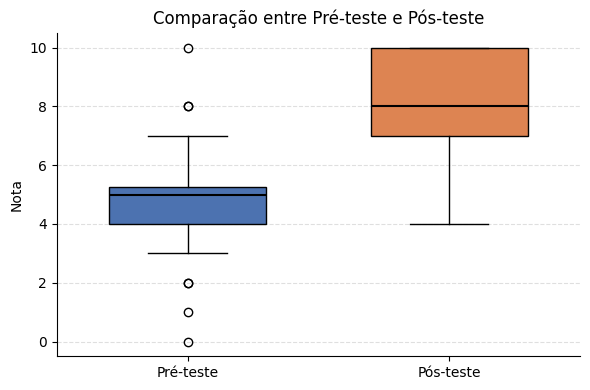

In [ ]:
import matplotlib.pyplot as plt

dados = [df["nota_pret"], df["nota_post"]]
labels = ["Pré-teste", "Pós-teste"]

plt.figure(figsize=(6,4))

box = plt.boxplot(
    dados,
    labels=labels,
    patch_artist=True,
    widths=0.6
)

cores = ["#4C72B0", "#DD8452"]

for patch, cor in zip(box['boxes'], cores):
    patch.set_facecolor(cor)
    patch.set_edgecolor("black")

for median in box['medians']:
    median.set_color("black")
    median.set_linewidth(1.5)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.title("Comparação entre Pré-teste e Pós-teste", fontsize=12)
plt.ylabel("Nota", fontsize=10)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

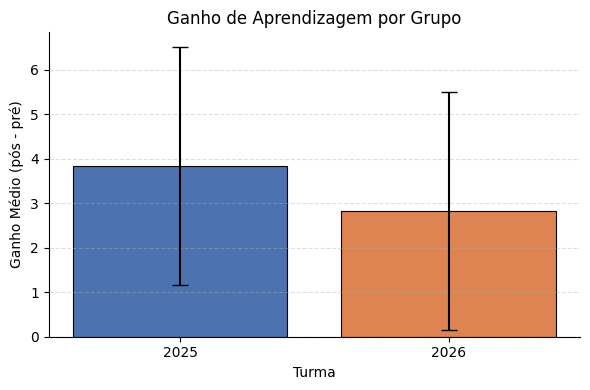

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

grupos = df.groupby("turma_ano")

medias = grupos["ganho_bruto"].mean()
stds = grupos["ganho_bruto"].std()

cores = ["#4C72B0", "#DD8452"]

plt.figure(figsize=(6,4))

bars = plt.bar(
    medias.index.astype(str),
    medias.values,
    yerr=stds.values,
    capsize=6,
    color=cores,
    edgecolor="black",
    linewidth=0.8
)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.title("Ganho de Aprendizagem por Grupo", fontsize=12)
plt.xlabel("Turma", fontsize=10)
plt.ylabel("Ganho Médio (pós - pré)", fontsize=10)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

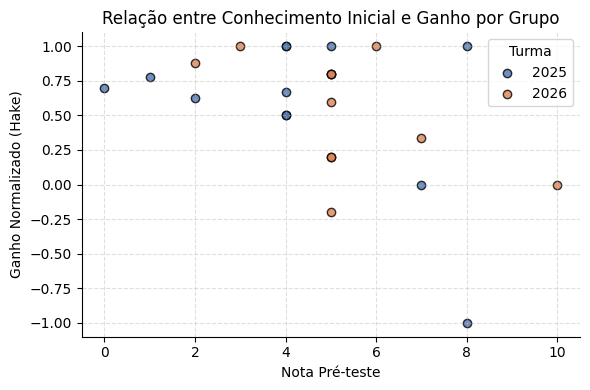

In [ ]:
cores = {2025: "#4C72B0", 2026: "#DD8452"}

plt.figure(figsize=(6,4))

for grupo in df["turma_ano"].unique():
    subset = df[df["turma_ano"] == grupo]
    plt.scatter(
        subset["nota_pret"],
        subset["ganho_hake"],
        label=str(grupo),
        color=cores[grupo],
        edgecolor="black",
        alpha=0.8
    )

plt.legend(title="Turma")
plt.grid(linestyle='--', alpha=0.4)

plt.xlabel("Nota Pré-teste", fontsize=10)
plt.ylabel("Ganho Normalizado (Hake)", fontsize=10)
plt.title("Relação entre Conhecimento Inicial e Ganho por Grupo", fontsize=12)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

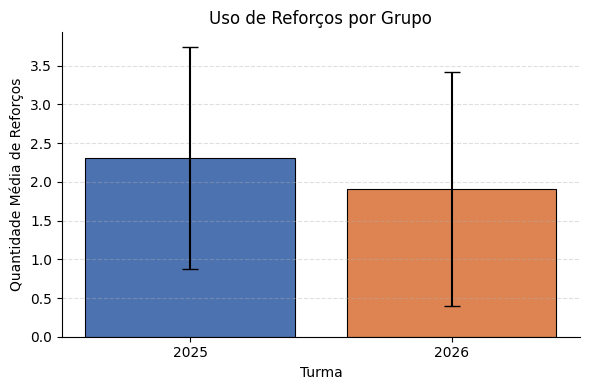

In [ ]:
import matplotlib.pyplot as plt

medias = grupos["qtd_reforcos"].mean()
stds = grupos["qtd_reforcos"].std()

cores = ["#4C72B0", "#DD8452"]

plt.figure(figsize=(6,4))

plt.bar(
    medias.index.astype(str),
    medias.values,
    yerr=stds.values,
    capsize=6,
    color=cores,
    edgecolor="black",
    linewidth=0.8
)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.title("Uso de Reforços por Grupo", fontsize=12)
plt.xlabel("Turma", fontsize=10)
plt.ylabel("Quantidade Média de Reforços", fontsize=10)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

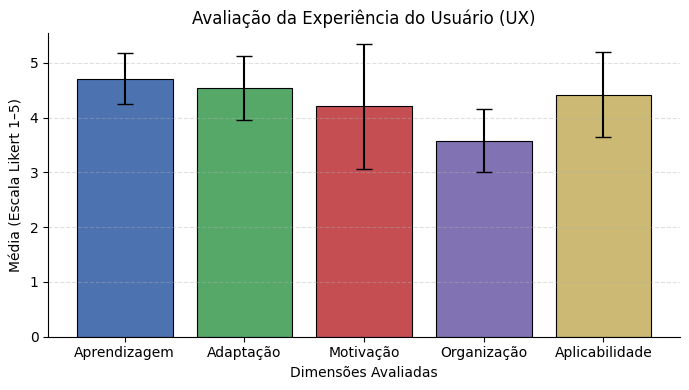

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

medias = df[["ux_01","ux_02","ux_03","ux_04","ux_05"]].mean()
stds = df[["ux_01","ux_02","ux_03","ux_04","ux_05"]].std()

cores = ["#4C72B0", "#55A868", "#C44E52", "#8172B3", "#CCB974"]

labels = [
    "Aprendizagem",
    "Adaptação",
    "Motivação",
    "Organização",
    "Aplicabilidade"
]

plt.figure(figsize=(7,4))

plt.bar(
    labels,
    medias.values,
    yerr=stds.values,
    capsize=6,
    color=cores,
    edgecolor="black",
    linewidth=0.8
)

plt.grid(axis='y', linestyle='--', alpha=0.4)

limite_superior = np.max(medias + stds) + 0.2
plt.ylim(0, limite_superior)

plt.title("Avaliação da Experiência do Usuário (UX)", fontsize=12)
plt.xlabel("Dimensões Avaliadas", fontsize=10)
plt.ylabel("Média (Escala Likert 1–5)", fontsize=10)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()